# 04 · Análisis
Lee `datos_procesados/datos_procesados_2024200482A.csv` (salida del cuaderno 03) y genera en `/salidas` todas las tablas (.xlsx con formato, .csv y .tex para LaTeX) y figuras (.png y .pdf) del artículo.



In [ ]:
# CELDA 0. Conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Nombres y apellidos: ASTETE ROSALES GRAYCE NICOL
# Código de matrícula: 2024200482A
# Tema N.º 2 del temario: El margen de intermediación financiera en el Perú: spread TAMN-TIPMN y sus determinantes
# Fecha de extracción:2026-09-25
# ============================================================================
# 04_analisis
# CELDA 1. Librerías, rutas y lectura de la base procesada
# Todas las tablas y figuras del artículo salen de este cuaderno (numeral 2.4.6).
# No hay procesos aleatorios, por lo que no se requiere semilla.
# ============================================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
try:
    from google.colab import data_table; data_table.disable_dataframe_formatter()
except ImportError:
    pass

CODIGO_MATRICULA = "2024200482A"
RAIZ = next(Path("/content/drive/MyDrive").rglob(f"datos_procesados_{CODIGO_MATRICULA}.csv")).parent.parent
DIR_SAL = RAIZ / "salidas"
DIR_SAL.mkdir(exist_ok=True)

df = pd.read_csv(RAIZ / "datos_procesados" / f"datos_procesados_{CODIGO_MATRICULA}.csv",
                 sep=";", decimal=",", encoding="utf-8-sig", parse_dates=["fecha"]).set_index("fecha")

FUENTE = "Fuente: elaboración propia con datos de la SBS (web scraping) y del BCRP (BCRPData, API)."
ETIQUETAS = {
    "tamn_pct": "TAMN (%)", "tipmn_pct": "TIPMN (%)", "spread_pct": "Spread TAMN-TIPMN (p.p.)",
    "tasa_referencia_pct": "Tasa de referencia (%)", "tasa_interbancaria_pct": "Tasa interbancaria (%)",
    "brecha_interbancaria_pct": "Brecha interbancaria (p.p.)", "riesgo_pais_embig_pct": "Riesgo país EMBIG (%)",
    "tipo_cambio_pen_usd": "Tipo de cambio (S/ por US$)",
}
print("Carpeta del proyecto:", RAIZ)
print(f"Base: {len(df)} días, de {df.index.min():%Y-%m-%d} a {df.index.max():%Y-%m-%d}")

Carpeta del proyecto: /content/drive/MyDrive/Base de datos y código Grayce Nicol Astete Rosales
Base: 1245 días, de 2021-01-04 a 2025-12-31


In [ ]:
# ============================================================================
# CELDA 2. Funciones para guardar tablas (Excel, CSV y LaTeX) y figuras (PNG y PDF)
# ============================================================================
from openpyxl.styles import Font, Alignment, Border, Side

def guardar_excel(tabla, nombre, titulo):
    """Guarda la tabla en Excel con título, encabezados en negrita, bordes y nota de fuente."""
    ruta = DIR_SAL / f"{nombre}.xlsx"
    with pd.ExcelWriter(ruta, engine="openpyxl") as xls:
        tabla.to_excel(xls, sheet_name="tabla", startrow=2)
        hoja = xls.sheets["tabla"]
        hoja["A1"] = titulo
        hoja["A1"].font = Font(bold=True, size=12)
        linea = Side(style="thin")
        ultima_fila = hoja.max_row
        for celda in hoja[3]:                                   # encabezados
            celda.font = Font(bold=True)
            celda.alignment = Alignment(horizontal="center", wrap_text=True)
            celda.border = Border(top=linea, bottom=linea)
        for celda in hoja[ultima_fila]:                         # línea final (estilo APA)
            celda.border = Border(bottom=linea)
        for fila in hoja.iter_rows(min_row=4, max_row=ultima_fila, min_col=2):
            for celda in fila:
                celda.alignment = Alignment(horizontal="right")
                if isinstance(celda.value, float):
                    celda.number_format = "0.000"
        hoja.cell(row=ultima_fila + 2, column=1, value=f"Nota. {FUENTE}").font = Font(italic=True, size=9)
        hoja.column_dimensions["A"].width = max(len(str(i)) for i in tabla.index) + 4
        for col in hoja.iter_cols(min_col=2, min_row=3, max_row=3):
            hoja.column_dimensions[col[0].column_letter].width = max(16, len(str(col[0].value)) + 2)

def guardar_tabla(tabla, nombre, titulo, decimales=3):
    """Guarda la tabla en .csv (para revisar) y en .tex (para pegar en el artículo en LaTeX)."""
    tabla.round(4).to_csv(DIR_SAL / f"{nombre}.csv", sep=";", decimal=",", encoding="utf-8-sig")  # se abre en columnas en Excel
    guardar_excel(tabla, nombre, titulo)                                                 # versión con formato
    def celda(v):
        if isinstance(v, (float, np.floating)):
            return "" if np.isnan(v) else f"{v:.{decimales}f}"
        return str(v)
    def limpio(t):
        return (str(t).replace("%", "\\%").replace("_", "\\_").replace("Δ", "$\\Delta$")
                .replace("²", "$^2$").replace("TAMN-TIPMN", "TAMN--TIPMN"))
    lineas = ["\\begin{table}[htbp]", "\\centering", f"\\caption{{{limpio(titulo)}}}",
              f"\\label{{tab:{nombre}}}", "\\small",
              "\\begin{tabular}{l" + "r" * tabla.shape[1] + "}", "\\toprule",
              " & ".join([""] + [limpio(c) for c in tabla.columns]) + " \\\\", "\\midrule"]
    for indice, fila in tabla.iterrows():
        lineas.append(" & ".join([limpio(indice)] + [limpio(celda(v)) for v in fila]) + " \\\\")
    lineas += ["\\bottomrule", "\\end{tabular}",
               f"\\par\\smallskip\\footnotesize\\textit{{Nota.}} {limpio(FUENTE)}", "\\end{table}"]
    (DIR_SAL / f"{nombre}.tex").write_text("\n".join(lineas), encoding="utf-8")
    print(f"Guardada: {nombre}.xlsx / .csv / .tex")

def guardar_figura(fig, nombre):
    fig.text(0.01, 0.005, FUENTE, fontsize=7, style="italic")
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(DIR_SAL / f"{nombre}.png", dpi=300)
    fig.savefig(DIR_SAL / f"{nombre}.pdf")
    plt.show()
    print(f"Guardada: {nombre}.png / .pdf")

def estrellas(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

In [ ]:
# ============================================================================
# CELDA 3. TABLA 1. Estadística descriptiva
# ============================================================================
variables = list(ETIQUETAS)
t1 = df[variables].describe().T[["count", "mean", "std", "min", "50%", "max"]]
t1.columns = ["N", "Media", "Desv. est.", "Mínimo", "Mediana", "Máximo"]
t1["N"] = t1["N"].astype(int).astype(str)
t1.index = [ETIQUETAS[v] for v in t1.index]
guardar_tabla(t1, "tabla1_descriptivos", "Estadística descriptiva de las variables (datos diarios)")
display(t1.round(3))

Guardada: tabla1_descriptivos.xlsx / .csv / .tex


,N,Media,Desv. est.,Mínimo,Mediana,Máximo
TAMN (%),1245,14.018,2.350,10.340,14.83,32.190
TIPMN (%),1245,2.353,0.992,0.750,2.36,4.100
Spread TAMN-TIPMN (p.p.),1245,11.665,1.787,9.560,11.76,29.890
Tasa de referencia (%),1245,4.789,2.406,0.250,5.00,7.750
Tasa interbancaria (%),1245,4.791,2.406,0.250,5.00,7.920
Brecha interbancaria (p.p.),1245,0.002,0.062,-0.910,0.00,0.500
Riesgo país EMBIG (%),1245,1.728,0.277,1.170,1.69,2.570
Tipo de cambio (S/ por US$),1245,3.759,0.155,3.359,3.75,4.138


In [ ]:
# ============================================================================
# CELDA 4. TABLA 2. Correlaciones y TABLA 3. Multicolinealidad (VIF)
# Un VIF mayor a 10 indica multicolinealidad grave entre los regresores.
# ============================================================================
vars_corr = ["spread_pct", "tasa_referencia_pct", "tasa_interbancaria_pct",
             "brecha_interbancaria_pct", "riesgo_pais_embig_pct", "tipo_cambio_pen_usd"]
t2 = df[vars_corr].corr()
t2.index = [f"({i}) {ETIQUETAS[v]}" for i, v in enumerate(vars_corr, 1)]
t2.columns = [f"({i})" for i in range(1, len(vars_corr) + 1)]
guardar_tabla(t2, "tabla2_correlaciones", "Matriz de correlaciones de Pearson", 2)
display(t2.round(2))

def tabla_vif(columnas):
    X = sm.add_constant(df[columnas])
    return pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])],
                     index=[ETIQUETAS[c] for c in columnas])

# Comparación: con referencia e interbancaria juntas vs. con la brecha interbancaria
con_ambas = ["tasa_referencia_pct", "tasa_interbancaria_pct", "riesgo_pais_embig_pct", "tipo_cambio_pen_usd"]
con_brecha = ["tasa_referencia_pct", "brecha_interbancaria_pct", "riesgo_pais_embig_pct", "tipo_cambio_pen_usd"]
t3 = pd.concat([tabla_vif(con_ambas).rename("VIF (referencia + interbancaria)"),
                tabla_vif(con_brecha).rename("VIF (referencia + brecha)")], axis=1)
guardar_tabla(t3, "tabla3_vif", "Factor de inflación de la varianza (VIF) de los regresores", 2)
display(t3.round(2))

Guardada: tabla2_correlaciones.xlsx / .csv / .tex


,(1),(2),(3),(4),(5),(6)
(1) Spread TAMN-TIPMN (p.p.),1.00,0.32,0.31,-0.07,-0.39,-0.47
(2) Tasa de referencia (%),0.32,1.00,1.00,-0.02,0.31,-0.17
(3) Tasa interbancaria (%),0.31,1.00,1.00,0.01,0.32,-0.16
(4) Brecha interbancaria (p.p.),-0.07,-0.02,0.01,1.00,0.09,0.02
(5) Riesgo país EMBIG (%),-0.39,0.31,0.32,0.09,1.00,0.59
(6) Tipo de cambio (S/ por US$),-0.47,-0.17,-0.16,0.02,0.59,1.00


Guardada: tabla3_vif.xlsx / .csv / .tex


,VIF (referencia + interbancaria),VIF (referencia + brecha)
Tasa de referencia (%),1502.05,1.41
Tasa interbancaria (%),1507.35,NaN
Riesgo país EMBIG (%),2.13,2.13
Tipo de cambio (S/ por US$),1.95,1.95
Brecha interbancaria (p.p.),NaN,1.02


In [ ]:
# ============================================================================
# CELDA 5. TABLA 4. Prueba de raíz unitaria de Dickey-Fuller aumentada (ADF)
# H0: la serie tiene raíz unitaria (no es estacionaria). Si p < 0.05 se rechaza H0.
# Si una serie es I(1), la regresión en niveles puede ser espuria: por eso
# se estima también el modelo en primeras diferencias (celda 6).
# ============================================================================
filas = []
for v in ["spread_pct", "tasa_referencia_pct", "brecha_interbancaria_pct",
          "riesgo_pais_embig_pct", "tipo_cambio_pen_usd"]:
    niv = adfuller(df[v], autolag="AIC")
    dif = adfuller(df[v].diff().dropna(), autolag="AIC")
    orden = "I(0)" if niv[1] < 0.05 else ("I(1)" if dif[1] < 0.05 else "Revisar")
    filas.append({"Variable": ETIQUETAS[v], "ADF niveles": niv[0], "p (niveles)": niv[1],
                  "ADF 1.a dif.": dif[0], "p (1.a dif.)": dif[1], "Orden de integración": orden})
t4 = pd.DataFrame(filas).set_index("Variable")
guardar_tabla(t4, "tabla4_raiz_unitaria", "Prueba de Dickey-Fuller aumentada (con constante)")
display(t4.round(3))

/tmp/ipykernel_695/1241173681.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  niv = adfuller(df[v], autolag="AIC")
/tmp/ipykernel_695/1241173681.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  dif = adfuller(df[v].diff().dropna(), autolag="AIC")
/tmp/ipykernel_695/1241173681.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on t

Guardada: tabla4_raiz_unitaria.xlsx / .csv / .tex


,ADF niveles,p (niveles),ADF 1.a dif.,p (1.a dif.),Orden de integración
Variable,,,,,
Spread TAMN-TIPMN (p.p.),-1.835,0.363,-13.045,0.000,I(1)
Tasa de referencia (%),-2.040,0.269,-2.990,0.036,I(1)
Brecha interbancaria (p.p.),-5.242,0.000,-11.085,0.000,I(0)
Riesgo país EMBIG (%),-2.724,0.070,-16.426,0.000,I(1)
Tipo de cambio (S/ por US$),-1.434,0.566,-19.260,0.000,I(1)


In [ ]:
# ============================================================================
# CELDA 6. TABLA 5. Determinantes del spread: MCO con errores Newey-West (HAC)
# Modelo (1) en niveles y modelo (2) en primeras diferencias (robustez).
# Se usa la BRECHA interbancaria en lugar de la tasa interbancaria para evitar
# la multicolinealidad con la tasa de referencia (ver tabla 3).
# Los errores Newey-West corrigen heterocedasticidad y autocorrelación.
# ============================================================================
explicativas = ["tasa_referencia_pct", "brecha_interbancaria_pct", "riesgo_pais_embig_pct", "tipo_cambio_pen_usd"]

def estimar(y, X):
    rezagos = int(np.floor(4 * (len(y) / 100) ** (2 / 9)))      # regla de Newey y West (1994)
    modelo = sm.OLS(y, sm.add_constant(X)).fit(cov_type="HAC", cov_kwds={"maxlags": rezagos})
    modelo.rezagos_nw = rezagos
    return modelo

m1 = estimar(df["spread_pct"], df[explicativas])
d = df[["spread_pct"] + explicativas].diff().dropna()
m2 = estimar(d["spread_pct"], d[explicativas])

def tabla_modelos(modelos):
    filas = {}
    for nombre, m in modelos.items():
        for var in m.params.index:
            etiqueta = "Constante" if var == "const" else ETIQUETAS[var]
            filas.setdefault(etiqueta, {})[nombre] = f"{m.params[var]:.4f}{estrellas(m.pvalues[var])}"
            filas.setdefault(etiqueta + " ", {})[nombre] = f"({m.bse[var]:.4f})"
    t = pd.DataFrame(filas).T
    t.index = [i if not i.endswith(" ") else "" for i in t.index]
    for etiqueta, valor in {"Observaciones": lambda m: f"{int(m.nobs)}",
                            "R²": lambda m: f"{m.rsquared:.3f}",
                            "R² ajustado": lambda m: f"{m.rsquared_adj:.3f}",
                            "Durbin-Watson": lambda m: f"{durbin_watson(m.resid):.3f}",
                            "Rezagos Newey-West": lambda m: str(m.rezagos_nw)}.items():
        t.loc[etiqueta] = [valor(m) for m in modelos.values()]
    return t

t5 = tabla_modelos({"(1) Niveles": m1, "(2) Primeras diferencias": m2})
guardar_tabla(t5, "tabla5_regresion_spread",
              "Determinantes del spread TAMN-TIPMN: MCO con errores Newey-West")
display(t5)
print("Errores estándar entre paréntesis. *** p<0.01, ** p<0.05, * p<0.10")
print(m1.summary())

Guardada: tabla5_regresion_spread.xlsx / .csv / .tex


,(1) Niveles,(2) Primeras diferencias
Constante,21.0718***,0.0095
,(1.4838),(0.0186)
Tasa de referencia (%),0.3195***,-1.9983
,(0.0215),(1.3117)
Brecha interbancaria (p.p.),-0.5072,-0.5792
,(0.5466),(0.3679)
Riesgo país EMBIG (%),-2.8299***,1.0037
,(0.2308),(1.1233)
Tipo de cambio (S/ por US$),-1.6091***,0.8513
,(0.4565),(2.1995)


Errores estándar entre paréntesis. *** p<0.01, ** p<0.05, * p<0.10
                            OLS Regression Results                            
Dep. Variable:             spread_pct   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     172.8
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          1.15e-117
Time:                        16:17:35   Log-Likelihood:                -2198.8
No. Observations:                1245   AIC:                             4408.
Df Residuals:                    1240   BIC:                             4433.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

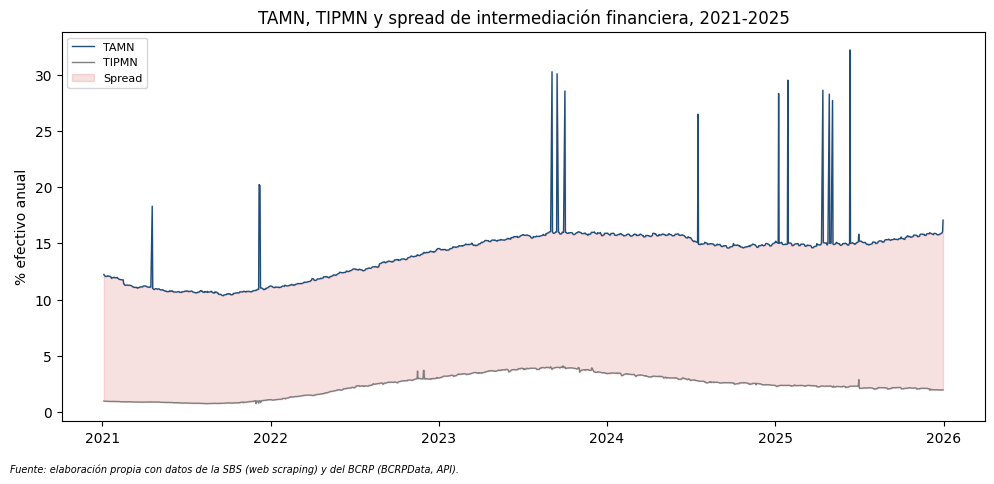

Guardada: figura1_tamn_tipmn_spread.png / .pdf


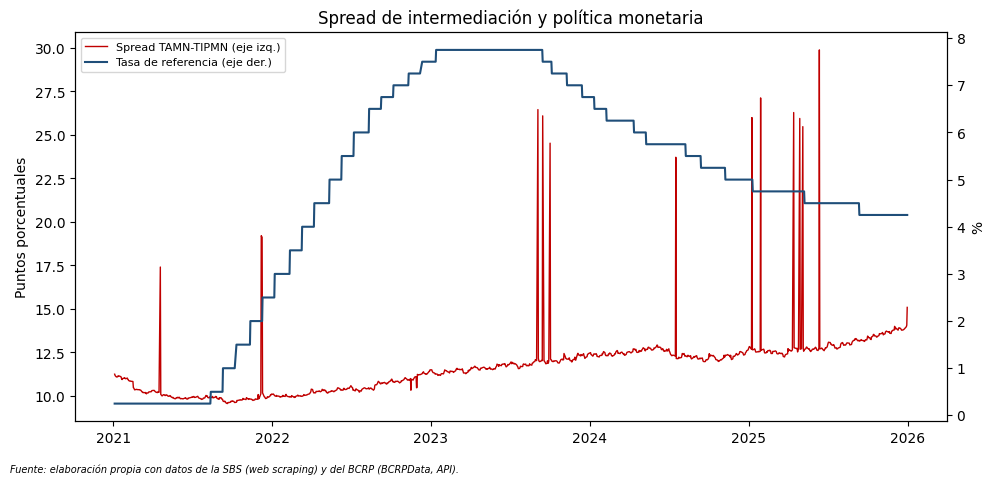

Guardada: figura2_spread_tasa_referencia.png / .pdf


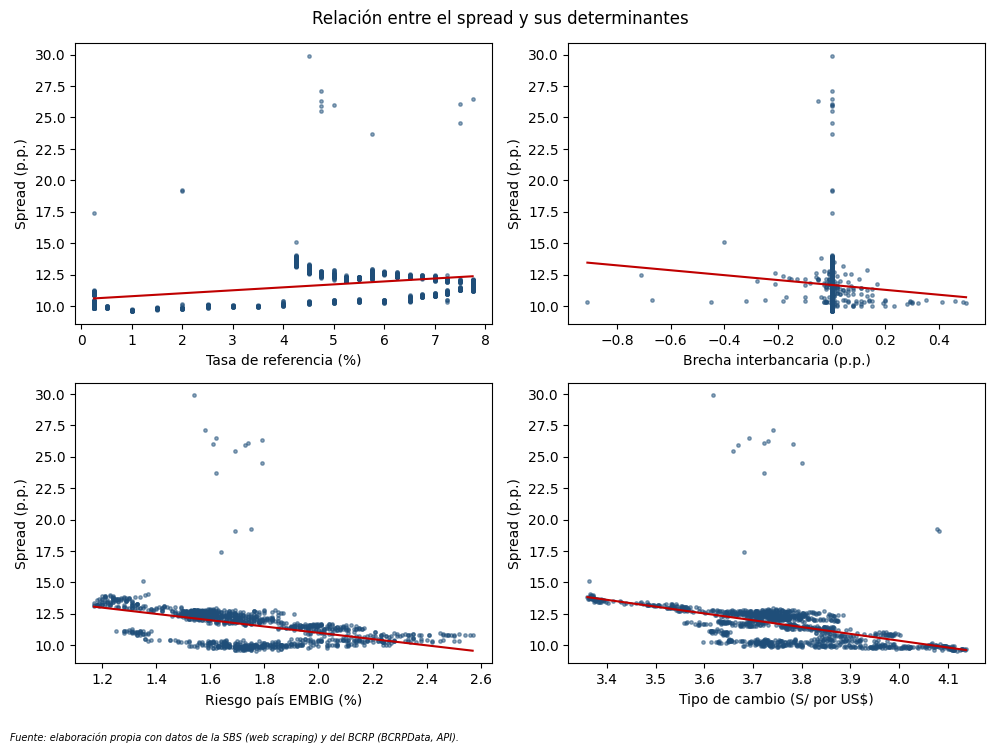

Guardada: figura3_dispersion_determinantes.png / .pdf


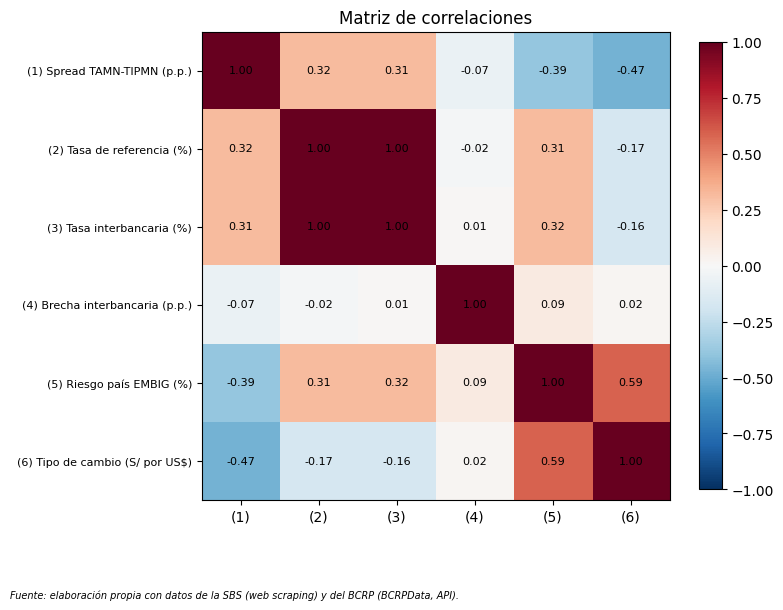

Guardada: figura4_correlaciones.png / .pdf


In [ ]:
# ============================================================================
# CELDA 7. Figuras del artículo
# ============================================================================
# FIGURA 1. TAMN, TIPMN y spread
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(df.index, df["tamn_pct"], color="#1f4e79", lw=1, label="TAMN")
ax.plot(df.index, df["tipmn_pct"], color="#7f7f7f", lw=1, label="TIPMN")
ax.fill_between(df.index, df["tipmn_pct"], df["tamn_pct"], color="#c00000", alpha=0.12, label="Spread")
ax.set_ylabel("% efectivo anual")
ax.set_title("TAMN, TIPMN y spread de intermediación financiera, 2021-2025")
ax.legend(loc="upper left", fontsize=8)
guardar_figura(fig, "figura1_tamn_tipmn_spread")

# FIGURA 2. Spread y tasa de referencia del BCRP
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(df.index, df["spread_pct"], color="#c00000", lw=1, label="Spread TAMN-TIPMN (eje izq.)")
ax2 = ax.twinx()
ax2.plot(df.index, df["tasa_referencia_pct"], color="#1f4e79", lw=1.5, label="Tasa de referencia (eje der.)")
ax.set_ylabel("Puntos porcentuales"); ax2.set_ylabel("%")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
ax.set_title("Spread de intermediación y política monetaria")
guardar_figura(fig, "figura2_spread_tasa_referencia")

# FIGURA 3. Spread frente a cada determinante (diagramas de dispersión)
fig, ejes = plt.subplots(2, 2, figsize=(10, 7.5))
for eje, var in zip(ejes.ravel(), explicativas):
    eje.scatter(df[var], df["spread_pct"], s=6, alpha=0.5, color="#1f4e79")
    b = np.polyfit(df[var], df["spread_pct"], 1)
    x = np.linspace(df[var].min(), df[var].max(), 50)
    eje.plot(x, np.polyval(b, x), color="#c00000", lw=1.5)
    eje.set_xlabel(ETIQUETAS[var]); eje.set_ylabel("Spread (p.p.)")
fig.suptitle("Relación entre el spread y sus determinantes")
guardar_figura(fig, "figura3_dispersion_determinantes")

# FIGURA 4. Mapa de calor de correlaciones
mat = df[vars_corr].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
nombres = [f"({i}) {ETIQUETAS[v]}" for i, v in enumerate(vars_corr, 1)]
ax.set_xticks(range(len(mat))); ax.set_xticklabels([f"({i})" for i in range(1, len(mat) + 1)])
ax.set_yticks(range(len(mat))); ax.set_yticklabels(nombres, fontsize=8)
for i in range(len(mat)):
    for j in range(len(mat)):
        ax.text(j, i, f"{mat.iat[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Matriz de correlaciones")
guardar_figura(fig, "figura4_correlaciones")

In [ ]:
# ============================================================================
# CELDA 8. Lectura rápida de resultados (guía para redactar la sección de resultados)
# ============================================================================
for nombre, m in {"Modelo (1) en niveles": m1, "Modelo (2) en diferencias": m2}.items():
    print(f"\n{nombre} | R² = {m.rsquared:.3f} | N = {int(m.nobs)}")
    for var in explicativas:
        signo = "aumenta" if m.params[var] > 0 else "reduce"
        sig = "significativo" if m.pvalues[var] < 0.05 else "NO significativo al 5 %"
        print(f"  - Un aumento de 1 unidad en {ETIQUETAS[var]} {signo} el spread en "
              f"{abs(m.params[var]):.4f} p.p. ({sig}, p = {m.pvalues[var]:.4f})")
print("\nArchivos generados en /salidas:")
for a in sorted(DIR_SAL.iterdir()):
    print("  ", a.name)


Modelo (1) en niveles | R² = 0.373 | N = 1245
  - Un aumento de 1 unidad en Tasa de referencia (%) aumenta el spread en 0.3195 p.p. (significativo, p = 0.0000)
  - Un aumento de 1 unidad en Brecha interbancaria (p.p.) reduce el spread en 0.5072 p.p. (NO significativo al 5 %, p = 0.3535)
  - Un aumento de 1 unidad en Riesgo país EMBIG (%) reduce el spread en 2.8299 p.p. (significativo, p = 0.0000)
  - Un aumento de 1 unidad en Tipo de cambio (S/ por US$) reduce el spread en 1.6091 p.p. (significativo, p = 0.0004)

Modelo (2) en diferencias | R² = 0.005 | N = 1244
  - Un aumento de 1 unidad en Tasa de referencia (%) reduce el spread en 1.9983 p.p. (NO significativo al 5 %, p = 0.1276)
  - Un aumento de 1 unidad en Brecha interbancaria (p.p.) reduce el spread en 0.5792 p.p. (NO significativo al 5 %, p = 0.1154)
  - Un aumento de 1 unidad en Riesgo país EMBIG (%) aumenta el spread en 1.0037 p.p. (NO significativo al 5 %, p = 0.3716)
  - Un aumento de 1 unidad en Tipo de cambio (S/ por US$

In [ ]:
# ============================================================================
# CELDA 9. Verificación de integridad: el hash de la base analizada debe
# coincidir con el registrado por el cuaderno 03 (numeral 2.4.6, verificación 3)
# ============================================================================
import hashlib
archivo = RAIZ / "datos_procesados" / f"datos_procesados_{CODIGO_MATRICULA}.csv"
hash_actual = hashlib.sha256(archivo.read_bytes()).hexdigest()
hash_registrado = (DIR_SAL / "hash_sha256.txt").read_text(encoding="utf-8").split()[0]
print("Hash de la base analizada :", hash_actual)
print("Hash registrado (03)      :", hash_registrado)
print("✅ Coinciden" if hash_actual == hash_registrado else "❌ NO coinciden: vuelva a ejecutar el cuaderno 03")

Hash de la base analizada : 0b57bc94ff94f1798cb40c2fd8bb266046345662631505e4917a56de2e1f8448
Hash registrado (03)      : 0b57bc94ff94f1798cb40c2fd8bb266046345662631505e4917a56de2e1f8448
✅ Coinciden
